In [3]:
import h5py
file = h5py.File('../jwst/f150w/f150w_A1.h5')
file.keys()

<KeysViewHDF5 ['a_image', 'axis_ratio', 'axis_ratio_err', 'b_image', 'chi2_max', 'dec', 'delta_f150w', 'flux_aper_f150w', 'flux_auto_f150w', 'flux_err_aper_f150w', 'flux_err_auto_f150w', 'id', 'id_specz_khostovan25', 'image', 'ml_morph_tag', 'morph_flag_f150w', 'ra', 'radius_sersic', 'radius_sersic_err', 'seg', 'segment-id', 'sersic', 'sersic_err', 'snr_f150w', 'theta_image', 'theta_world', 'tile', 'x_image', 'y_image']>

In [3]:
file['id'],file['image']

(<HDF5 dataset "id": shape (31359,), type "<i8">,
 <HDF5 dataset "image": shape (31359, 128, 128), type "<f4">)

In [8]:
#check how many. nan in radius sersic
import numpy as np
file['seg'].shape

(31359, 128, 128)

{'split': 'train', 'root': '/ptmp/yacheng/outthere_ssl/images/cosmos_2025/outputs/', 'filter': 'f115w'}


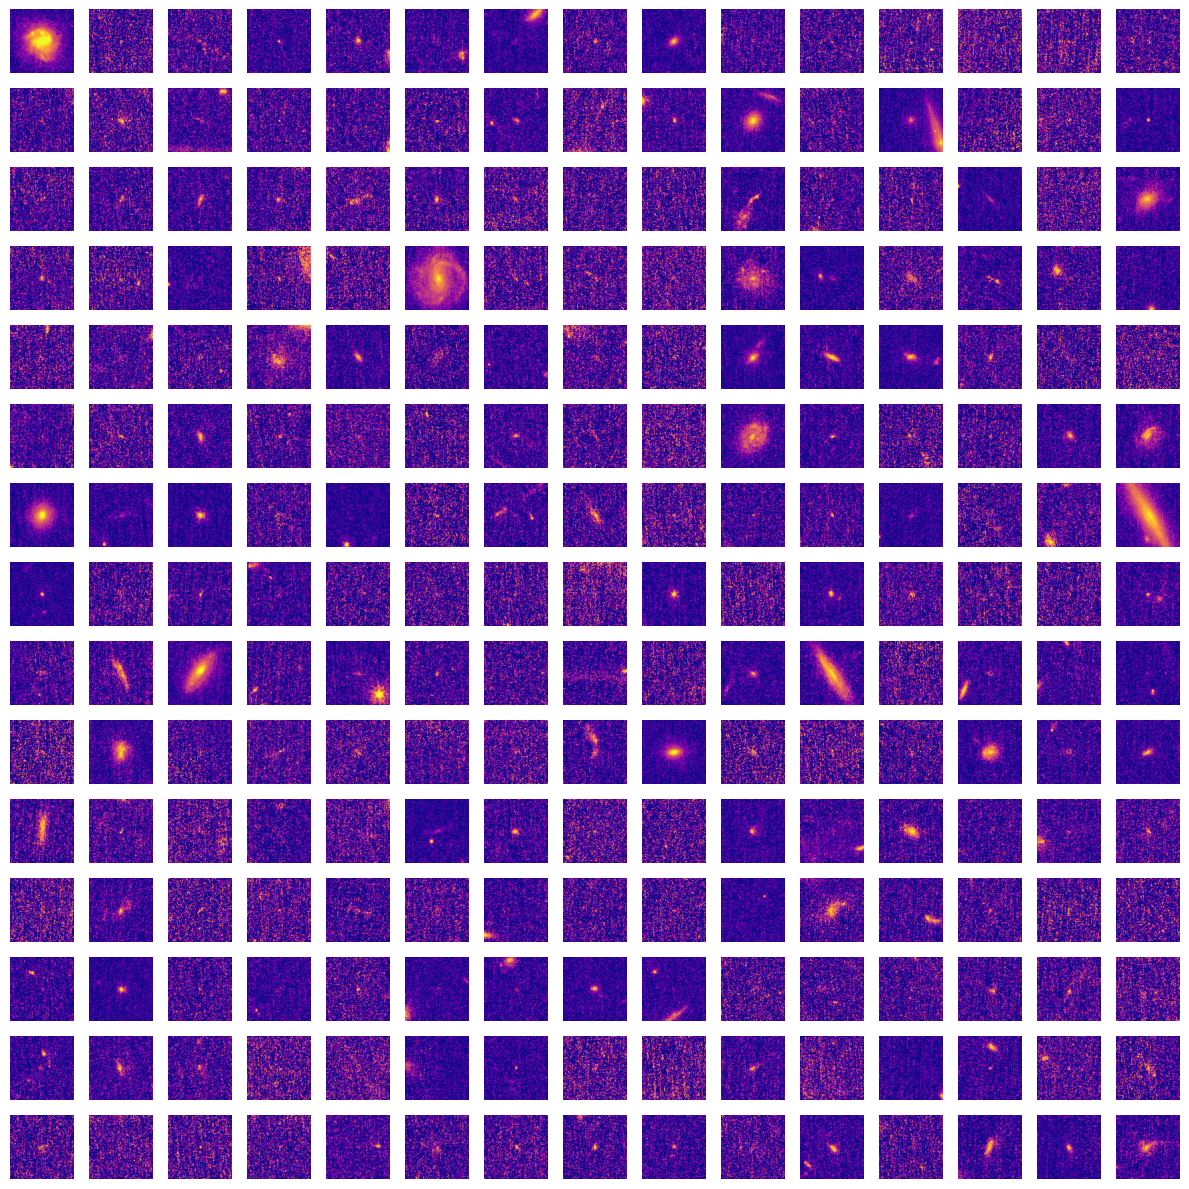

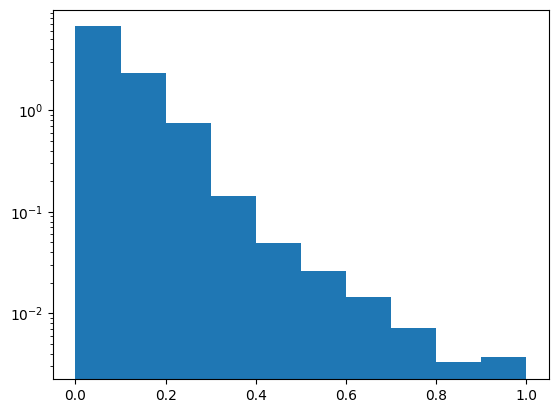

In [8]:
crop_size = 72

transform = transforms.Compose(
    [
        transforms.CenterCrop(crop_size),
        ToRGB(Q=20,m=0.01),
    ]
)

dataset = make_dataset(
    dataset_str="jwst:split=train:root=/ptmp/yacheng/outthere_ssl/images/cosmos_2025/outputs/:filter=f115w",
    transform=transform,
    channel=0,
)

#make a 8x8 subplot to check the images
start_index=35307
grid_size = 15
import matplotlib.pyplot as plt
fig, axs = plt.subplots(grid_size, grid_size, figsize=(12, 12))
hist_data = []
for i in range(grid_size):
    for j in range(grid_size):
        img, _ = dataset[i * grid_size + j+start_index]
        hist_data.append(img[0])
        axs[i, j].imshow(img[0],cmap='plasma')
        axs[i, j].axis('off')
plt.tight_layout()
plt.show()
    
plt.hist(np.array(hist_data).flatten(),density=True)
plt.yscale('log')
    

{'split': 'train', 'root': '/ptmp/yacheng/outthere_ssl/', 'extra': '""'}


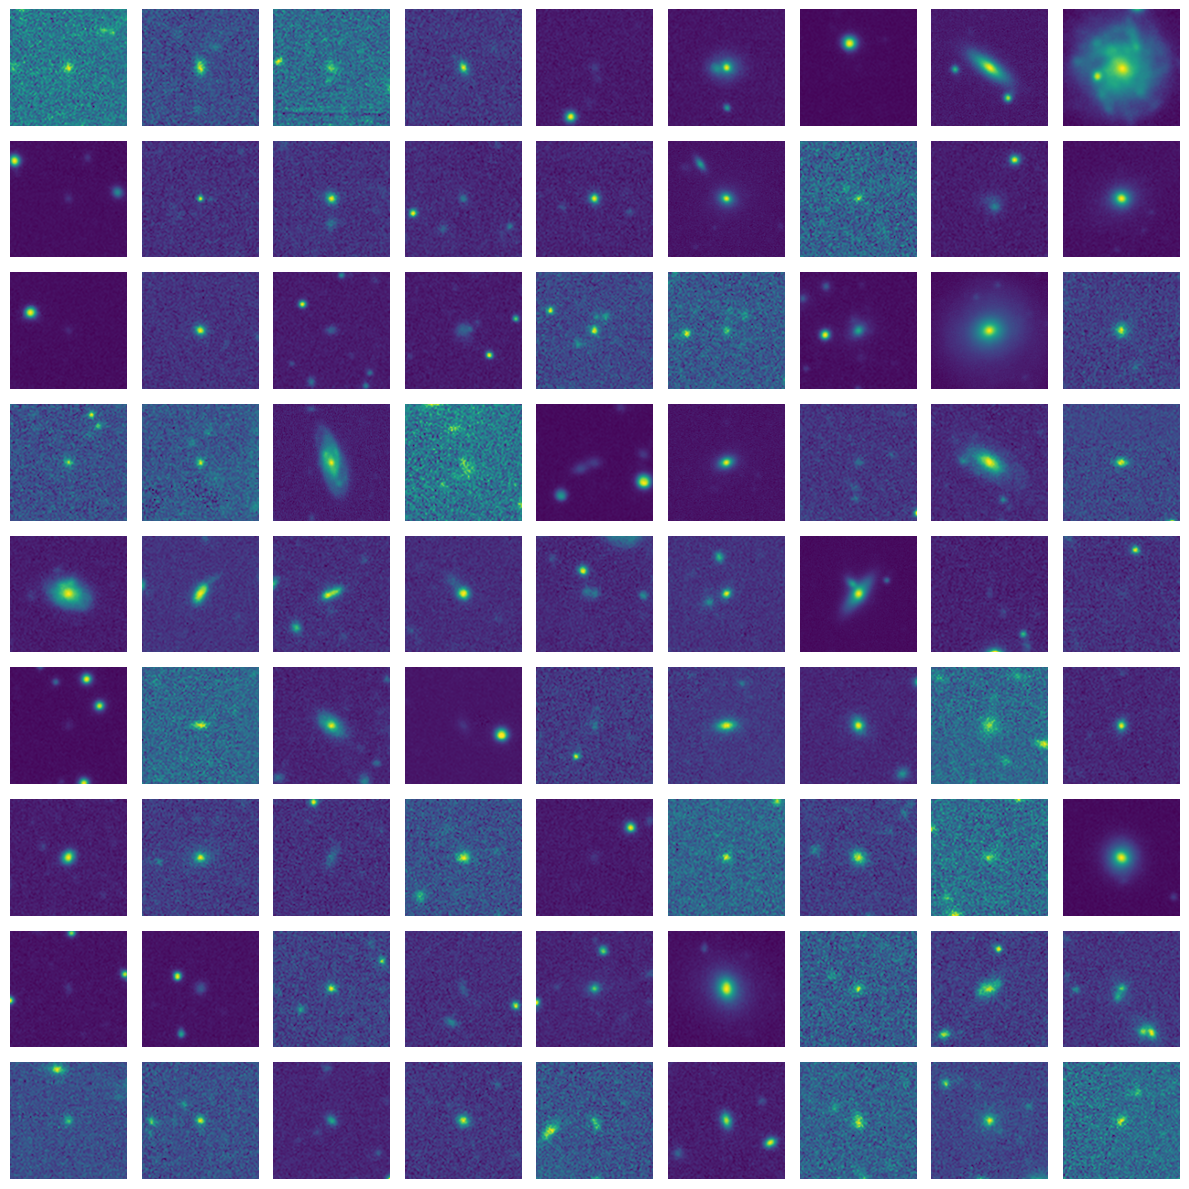

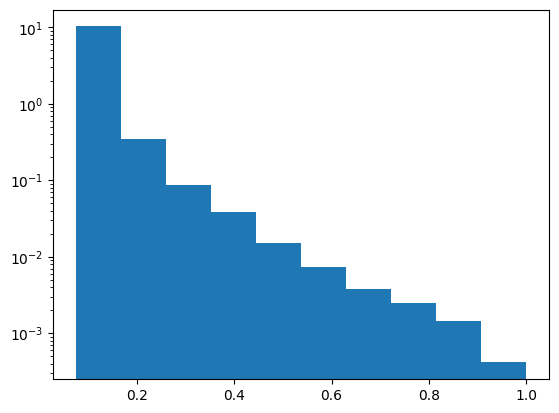

In [93]:
crop_size = 128

transform = transforms.Compose(
    [
        transforms.CenterCrop(crop_size),
        ToRGB(),
    ]
)

dataset = make_dataset(
    dataset_str="LegacySurvey:split=train:root=/ptmp/yacheng/outthere_ssl/:extra=\"\"",
    transform=transform,
    channel=0,
)

#make a 8x8 subplot to check the images
start_index=9060
grid_size = 9
import matplotlib.pyplot as plt
fig, axs = plt.subplots(grid_size, grid_size, figsize=(12, 12))
hist_data = []
for i in range(grid_size):
    for j in range(grid_size):
        img, _ = dataset[i * grid_size + j+start_index]
        hist_data.append(img[0])
        axs[i, j].imshow(img[0])
        axs[i, j].axis('off')
plt.tight_layout()
plt.show()
    
plt.hist(np.array(hist_data).flatten(),density=True)
plt.yscale('log')
    